<a href="https://colab.research.google.com/github/tejaswipriya22/Tejaswi_Ml-on-big-data/blob/main/week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, mean, when, isnull

In [ ]:
spark = SparkSession.builder \
                    .appName("Tutorial_DF") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()

In [ ]:
spark

In [ ]:
# Load CSV into DataFrame
file_path = "/content/Airline_Delay_Cause.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Show the first 5 rows
print("Showing first 5 rows:")
df.show(5)

# Print schema of the DataFrame
print("Schema of DataFrame:")
df.printSchema(1)

Showing first 5 rows:
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        

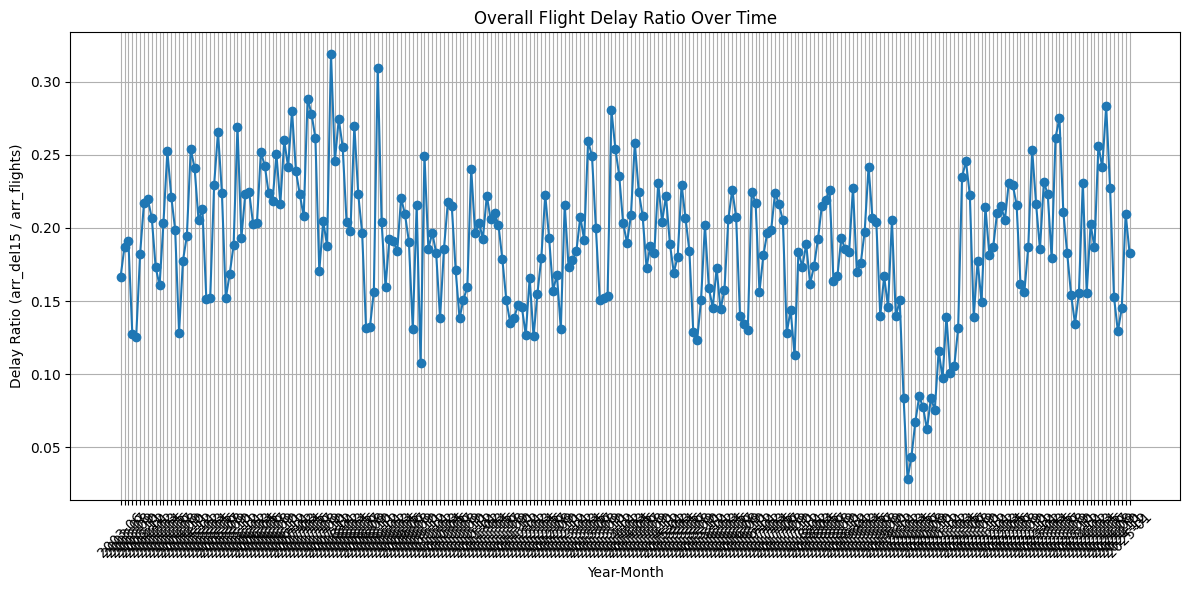

In [ ]:
import matplotlib.pyplot as plt

# Group by year and month to get total flights and delayed flights
delay_trend = df.groupBy("year", "month") \
    .agg({"arr_flights": "sum", "arr_del15": "sum"}) \
    .withColumnRenamed("sum(arr_flights)", "total_flights") \
    .withColumnRenamed("sum(arr_del15)", "total_delays")

# Calculate the delay ratio
delay_trend = delay_trend.withColumn("delay_ratio", col("total_delays") / col("total_flights"))

# Convert to Pandas for plotting
pdf = delay_trend.orderBy("year", "month").toPandas()

# Create a 'Date' column for better plotting
pdf['date'] = pdf.apply(lambda x: f"{int(x['year'])}-{int(x['month']):02d}", axis=1)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(pdf['date'], pdf['delay_ratio'], marker='o', linestyle='-')
plt.title('Overall Flight Delay Ratio Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Delay Ratio (arr_del15 / arr_flights)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_945/2916982622.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="delay_rate", y="carrier_name", data=carrier_pdf, palette="magma")


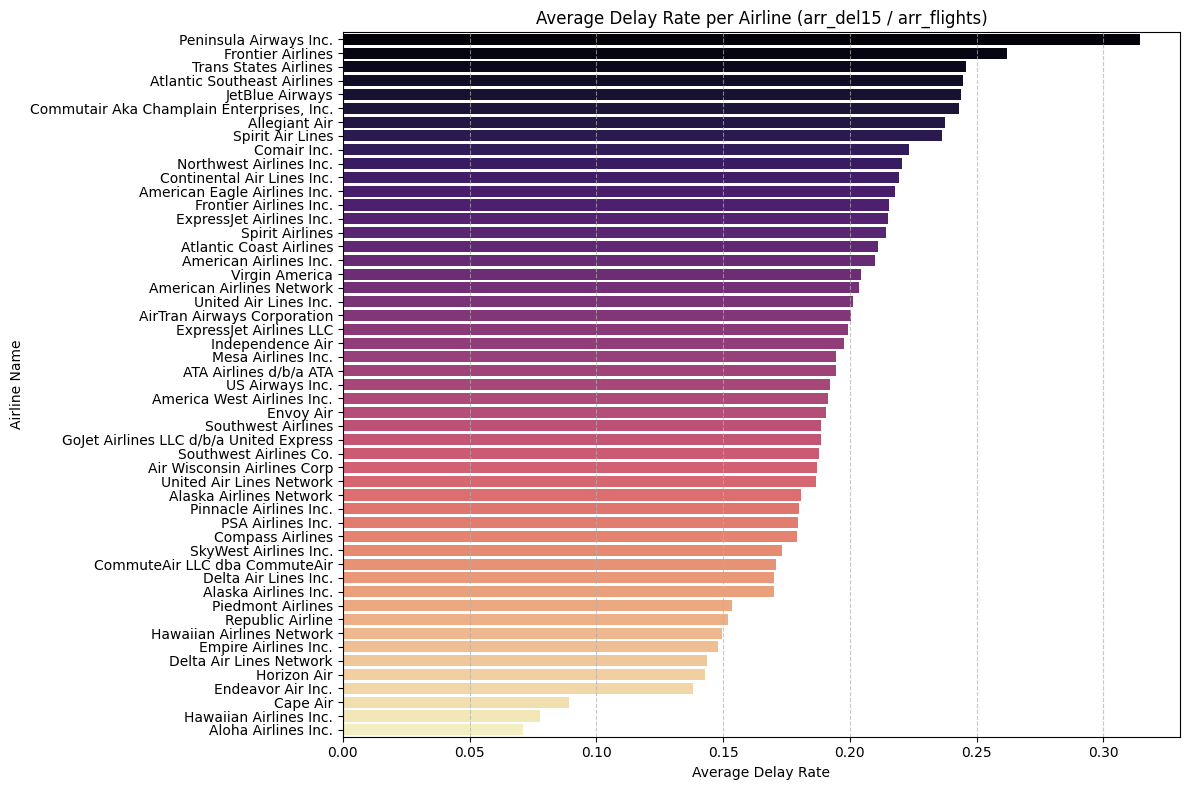

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by carrier_name and sum the relevant columns
carrier_delays = df.groupBy("carrier_name") \
    .agg({"arr_flights": "sum", "arr_del15": "sum"}) \
    .withColumnRenamed("sum(arr_flights)", "total_flights") \
    .withColumnRenamed("sum(arr_del15)", "total_delays")

# Calculate delay rate
carrier_delays = carrier_delays.withColumn("delay_rate", col("total_delays") / col("total_flights")) \
    .orderBy(col("delay_rate").desc())

# Convert to Pandas for plotting
carrier_pdf = carrier_delays.toPandas()

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x="delay_rate", y="carrier_name", data=carrier_pdf, palette="magma")
plt.title("Average Delay Rate per Airline (arr_del15 / arr_flights)")
plt.xlabel("Average Delay Rate")
plt.ylabel("Airline Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

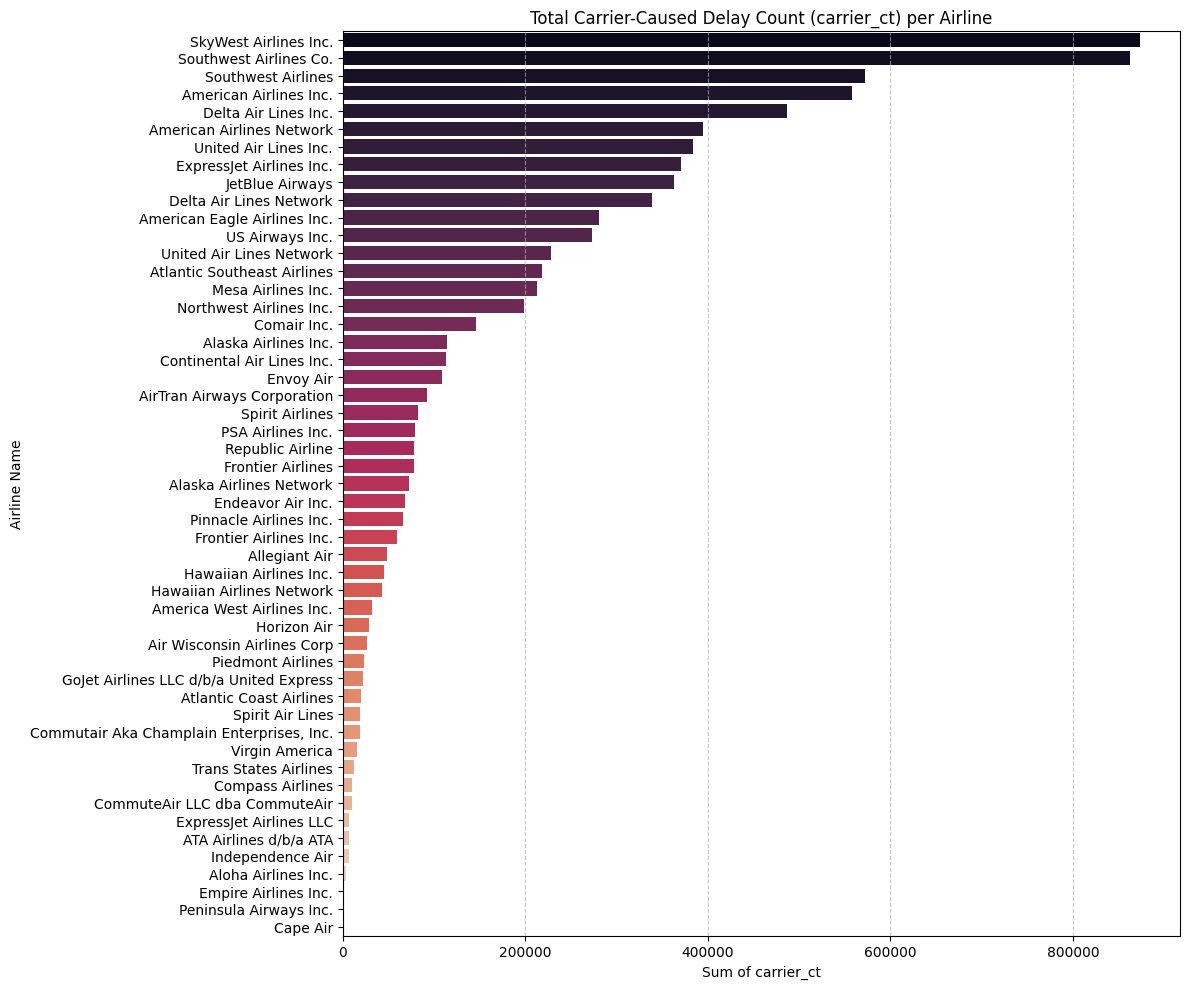

In [ ]:
# Group by carrier_name and sum carrier_ct
carrier_caused_delays = df.groupBy("carrier_name") \
    .agg({"carrier_ct": "sum"}) \
    .withColumnRenamed("sum(carrier_ct)", "total_carrier_ct") \
    .orderBy(col("total_carrier_ct").desc())

# Convert to Pandas for plotting
carrier_ct_pdf = carrier_caused_delays.toPandas()

# Plotting
plt.figure(figsize=(12, 10))
sns.barplot(x="total_carrier_ct", y="carrier_name", data=carrier_ct_pdf, hue="carrier_name", palette="rocket", legend=False)
plt.title("Total Carrier-Caused Delay Count (carrier_ct) per Airline")
plt.xlabel("Sum of carrier_ct")
plt.ylabel("Airline Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

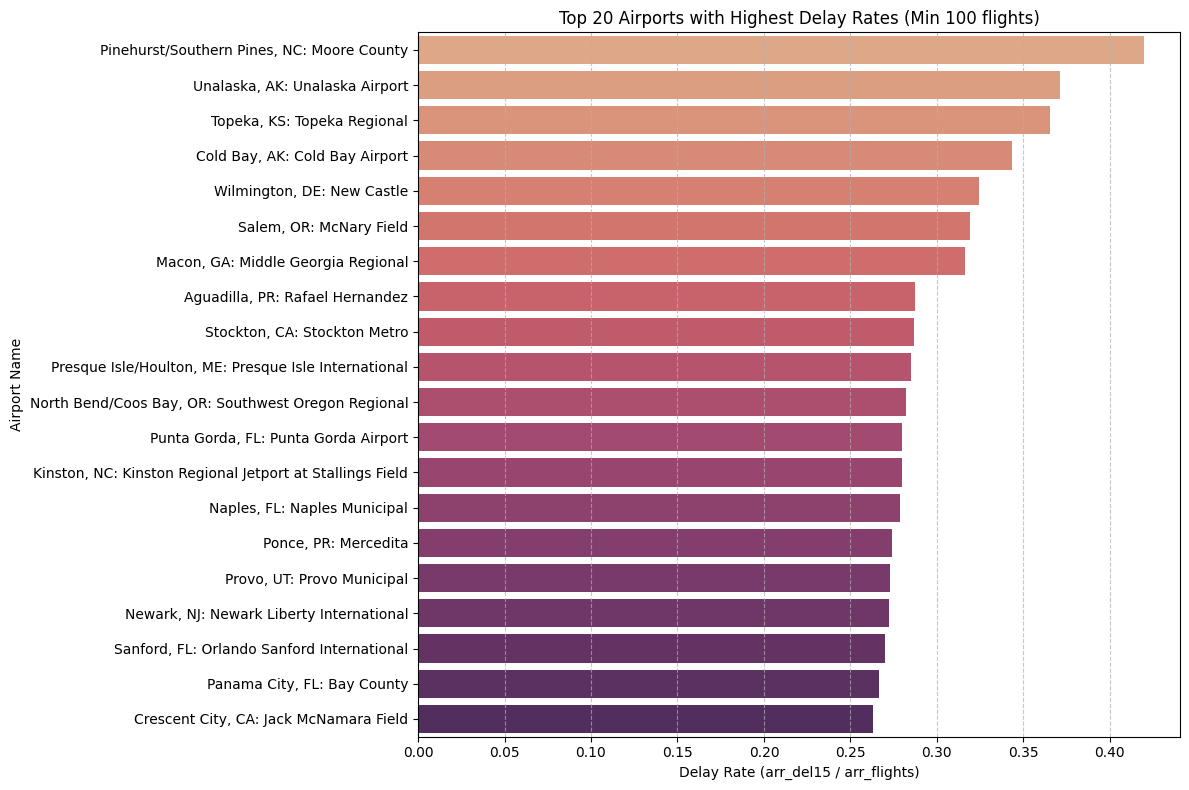

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by airport and sum flights and delays
airport_delays = df.groupBy("airport", "airport_name") \
    .agg({"arr_flights": "sum", "arr_del15": "sum"}) \
    .withColumnRenamed("sum(arr_flights)", "total_flights") \
    .withColumnRenamed("sum(arr_del15)", "total_delays")

# Filter out airports with very low traffic to avoid outliers, then calculate rate
airport_delays = airport_delays.filter(col("total_flights") > 100) \
    .withColumn("delay_rate", col("total_delays") / col("total_flights")) \
    .orderBy(col("delay_rate").desc())

# Take the top 20 for better visualization
airport_pdf = airport_delays.limit(20).toPandas()

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x="delay_rate", y="airport_name", data=airport_pdf, hue="airport_name", palette="flare", legend=False)
plt.title("Top 20 Airports with Highest Delay Rates (Min 100 flights)")
plt.xlabel("Delay Rate (arr_del15 / arr_flights)")
plt.ylabel("Airport Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

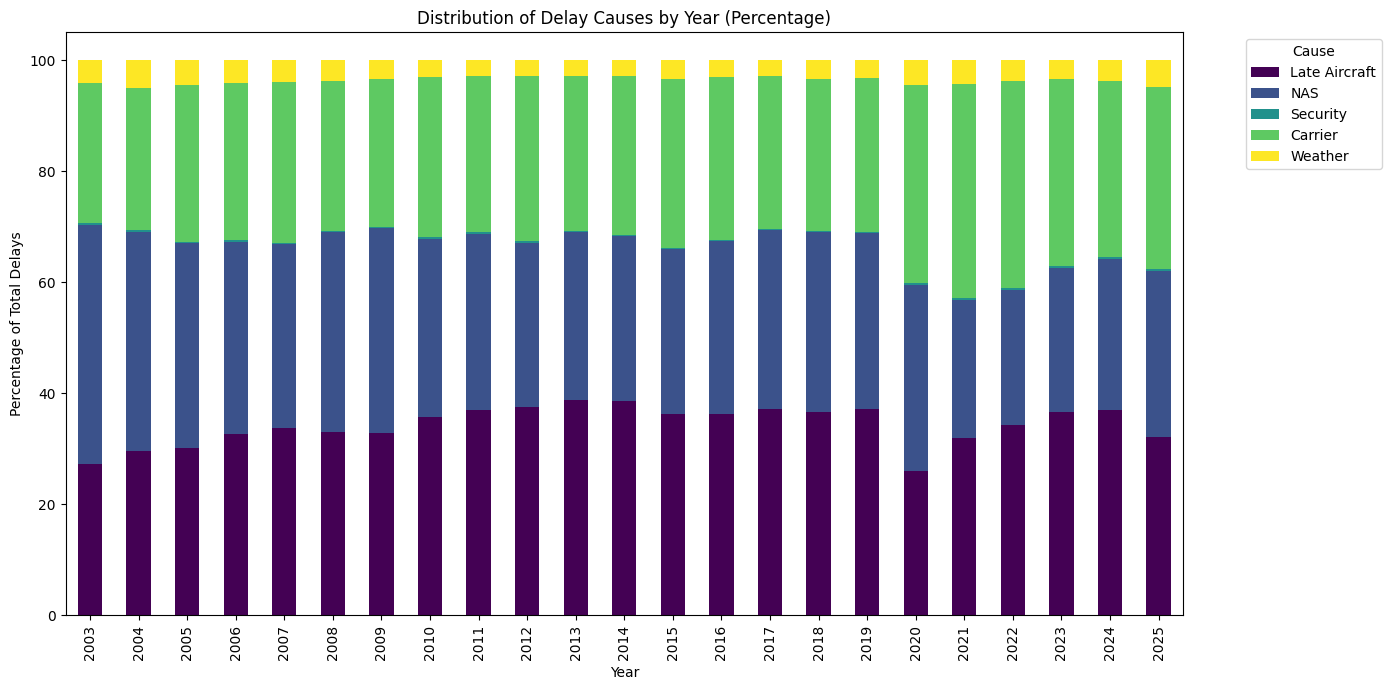

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate all delay cause counts by year
causes_df = df.groupBy("year") \
    .agg({
        "carrier_ct": "sum",
        "weather_ct": "sum",
        "nas_ct": "sum",
        "security_ct": "sum",
        "late_aircraft_ct": "sum"
    }) \
    .toPandas()

# Rename columns for clarity
causes_df = causes_df.rename(columns={
    "sum(carrier_ct)": "Carrier",
    "sum(weather_ct)": "Weather",
    "sum(nas_ct)": "NAS",
    "sum(security_ct)": "Security",
    "sum(late_aircraft_ct)": "Late Aircraft"
})

# Set year as index and sort
causes_df = causes_df.set_index("year").sort_index()

# Convert to percentages for the stacked bar chart
causes_perc = causes_df.div(causes_df.sum(axis=1), axis=0) * 100

# Plotting
causes_perc.plot(kind='bar', stacked=True, figsize=(14, 7), colormap="viridis")
plt.title("Distribution of Delay Causes by Year (Percentage)")
plt.ylabel("Percentage of Total Delays")
plt.xlabel("Year")
plt.legend(title="Cause", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

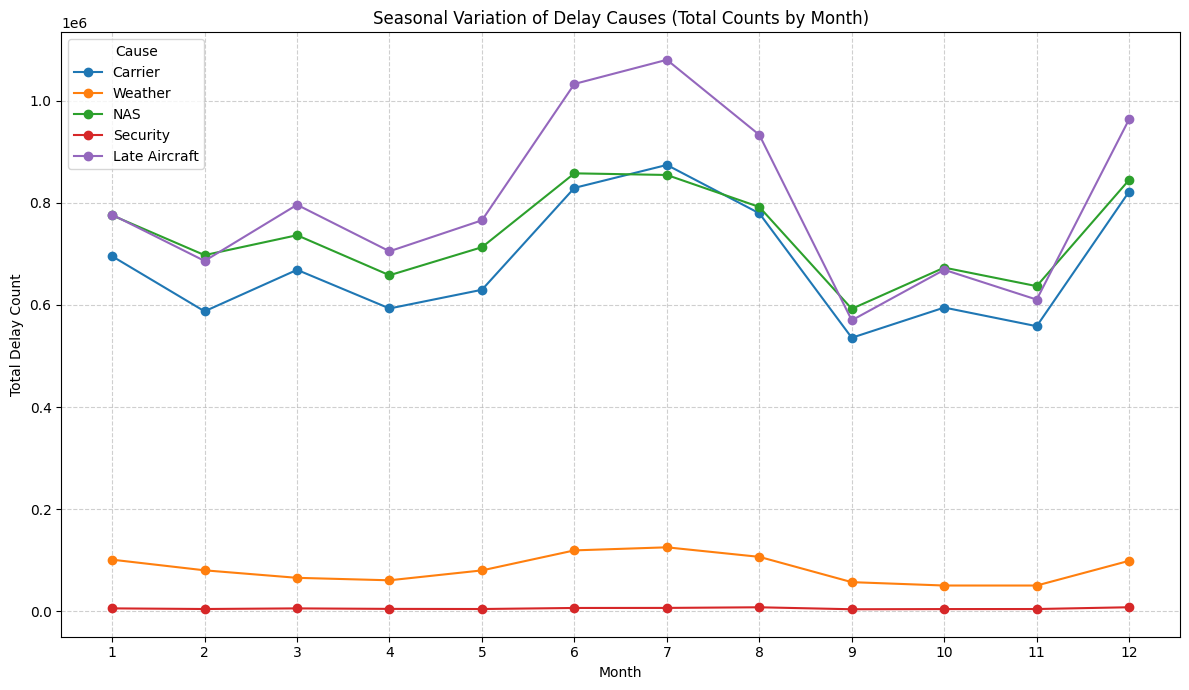

In [ ]:
seasonal_causes = df.groupBy("month") \
    .agg({
        "carrier_ct": "sum",
        "weather_ct": "sum",
        "nas_ct": "sum",
        "security_ct": "sum",
        "late_aircraft_ct": "sum"
    }) \
    .toPandas()

# Rename columns for clarity
seasonal_causes = seasonal_causes.rename(columns={
    "sum(carrier_ct)": "Carrier",
    "sum(weather_ct)": "Weather",
    "sum(nas_ct)": "NAS",
    "sum(security_ct)": "Security",
    "sum(late_aircraft_ct)": "Late Aircraft"
})

# Sort by month
seasonal_causes = seasonal_causes.sort_values("month")

# Plotting
plt.figure(figsize=(12, 7))
for column in ["Carrier", "Weather", "NAS", "Security", "Late Aircraft"]:
    plt.plot(seasonal_causes["month"], seasonal_causes[column], marker='o', label=column)

plt.title("Seasonal Variation of Delay Causes (Total Counts by Month)")
plt.xlabel("Month")
plt.ylabel("Total Delay Count")
plt.xticks(range(1, 13))
plt.legend(title="Cause")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

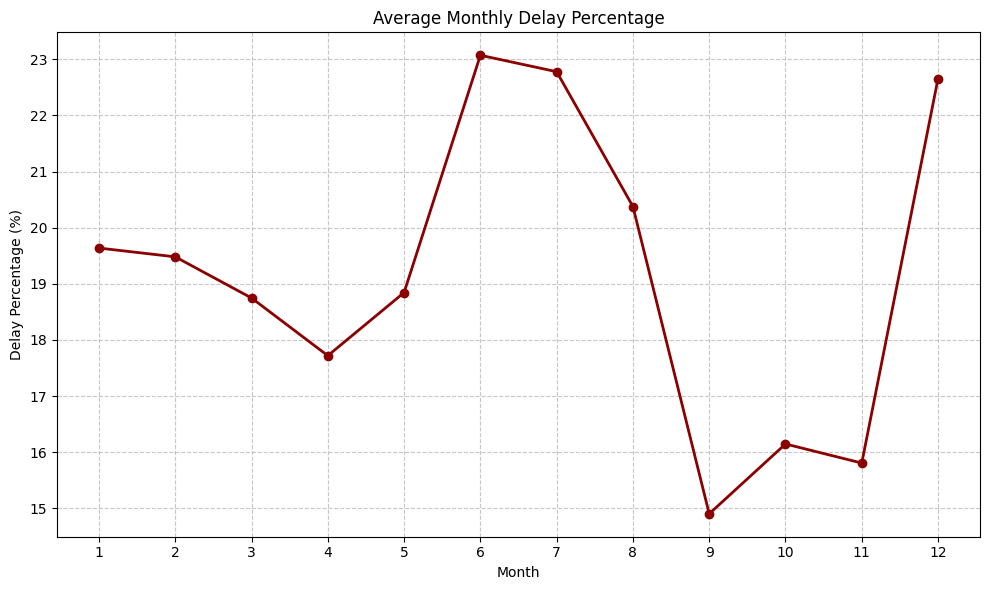

In [ ]:
monthly_delays = df.groupBy("month") \
    .agg({"arr_flights": "sum", "arr_del15": "sum"}) \
    .withColumnRenamed("sum(arr_flights)", "total_flights") \
    .withColumnRenamed("sum(arr_del15)", "total_delays")

# Calculate delay percentage
monthly_delays = monthly_delays.withColumn("delay_percentage", (col("total_delays") / col("total_flights")) * 100) \
    .orderBy("month")

# Convert to Pandas for plotting
monthly_pdf = monthly_delays.toPandas()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(monthly_pdf['month'], monthly_pdf['delay_percentage'], marker='o', linewidth=2, color='darkred')
plt.title("Average Monthly Delay Percentage")
plt.xlabel("Month")
plt.ylabel("Delay Percentage (%)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()